In [2]:
import pyphi
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'



In [5]:
!pip install pandas



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 7.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]


In [6]:
import pandas as pd


In [7]:
df = pd.read_csv("tpm_output.csv")


In [11]:
print (df)

    0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.54  0.55  0.56  \
0   0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
1   0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
2   0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
3   0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
4   0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
.. ..  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   ...   ...   
58  0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
59  0    0    0    1    0    0    0    0    0    0  ...     0     0     0   
60  0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
61  0    0    0    0    0    0    0    0    0    0  ...     0     0     0   
62  0    0    0    0    0    0    0    0    0    0  ...     0     0     0   

    0.57  0.58  0.59  0.60  0.61  0.62  0.63  
0      0     0     0     0  

In [19]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 6.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 6.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]32m5/6 [torch]]x]


In [21]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] [torchvision]


# MINST CLASSIFICATION

## FINDING THE TPM MATRIX OF MINST CLASSIFICATION WITH SINGLE LAYER

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np

# 1. Setup & Load MNIST

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)


# 2. Define Small MLP (6 hidden neurons)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 6)   # small hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(6, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        h = self.fc1(x)
        self.hidden = h.detach()      # save raw hidden activations
        x = self.relu(h)
        x = self.fc2(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# 3. Model Train
epochs = 5
model.train()
for epoch in range(epochs):
    for batch_idx, (images, labels) in enumerate(train_loader):
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


# 4. After Training: Capture 201 Samples
model.eval()
activation_list = []
data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
    for i, (img, label) in enumerate(data_loader):
        _ = model(img)
        activation = model.hidden.squeeze().numpy()  # shape: (6,)
        activation_list.append(activation)

        if i >= 200:  # capture 201 samples → 200 transitions
            break

# 5. Binarize the Activations

activations = np.array(activation_list)  # shape: (201, 6)

# Method: Median threshold per neuron
thresholds = np.median(activations, axis=0)
binarized = (activations > thresholds).astype(int)  # shape: (201, 6)

#  Ready for TPM Construction

print("Sample binarized activations (first 5 rows):")
print(binarized[:20])

# 6. Evaluate Accuracy on Test Set
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\nTest Accuracy: {accuracy:.2f}%")



Epoch 1/5, Loss: 0.7486
Epoch 2/5, Loss: 0.1833
Epoch 3/5, Loss: 0.3228
Epoch 4/5, Loss: 0.3433
Epoch 5/5, Loss: 0.6553
Sample binarized activations (first 5 rows):
[[1 1 0 0 1 0]
 [1 1 0 0 0 0]
 [0 0 0 1 0 1]
 [0 0 1 1 0 1]
 [0 0 1 0 1 1]
 [1 1 1 0 0 0]
 [0 1 1 1 0 1]
 [1 1 1 0 1 0]
 [0 0 1 1 0 1]
 [0 0 0 1 0 1]
 [1 1 1 0 1 0]
 [1 0 0 1 0 1]
 [1 1 1 0 1 0]
 [1 0 1 1 0 0]
 [0 0 1 1 0 1]
 [0 0 0 0 1 1]
 [0 0 0 1 0 1]
 [1 1 1 0 1 0]
 [1 0 0 1 0 1]
 [0 0 0 0 1 1]]

Test Accuracy: 86.19%


In [2]:
import numpy as np
from itertools import product
from collections import defaultdict

# Generate all possible binary states (for 6 neurons)
n = binarized.shape[1]  # number of neurons
all_states = [tuple(state) for state in product([0, 1], repeat=n)]
state_to_index = {state: i for i, state in enumerate(all_states)}

#Initialization of raw transition count matrix
counts = np.zeros((2**n, 2**n))

# Looping through transitions and count
for t in range(len(binarized) - 1):
    current_state = tuple(binarized[t])
    next_state = tuple(binarized[t + 1])

    i = state_to_index[current_state]
    j = state_to_index[next_state]

    counts[i][j] += 1

# Normalizing each row to get transition probabilities
tpm = np.zeros_like(counts)
for i in range(counts.shape[0]):
    row_sum = counts[i].sum()
    if row_sum > 0:
        tpm[i] = counts[i] / row_sum  

# TPM
print(f"TPM shape: {tpm.shape}")  



TPM shape: (64, 64)


# MNIST_WHEN_NEURONS_ARE_CONNECTED_TO_EACH_OTHER

In [22]:
import numpy as np
import pandas as pd
import pyphi
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False


#Number of nodes (2^6 = 64)
num_nodes = int(np.log2(tpm.shape[0]))

# Connectivity matrix
connectivity = np.ones((num_nodes, num_nodes), dtype=int) - np.eye(num_nodes, dtype=int)

# Creation of PyPhi network
node_labels = ('0','1','2','3','4','5')
network = pyphi.Network(tpm, connectivity, node_labels)

# Initial state(0,0,0,0,0,0)
state = tuple([0] * num_nodes)

pyphi.config.VALIDATE_SUBSYSTEM_STATES = False


subsystem = pyphi.Subsystem(network, state)
phi = pyphi.compute.sia(subsystem)

print(f"Φ (phi) for state {state} = {phi}")


Computing concepts:  89%|████████████████████▍  | 56/63 [00:16<00:02,  2.96it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'



Computing concepts:  90%|████████████████████▊  | 57/63 [00:19<00:06,  1.03s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'



Computing concepts:  94%|█████████████████████▌ | 59/63 [00:20<00:03,  1.27it/s]

...

Evaluating Φ cuts:  98%|███████████████████████▌| 61/62 [15:38<00:10, 10.23s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'



Evaluating Φ cuts: 100%|████████████████████████| 62/62 [15:43<00:00,  8.83s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'



Φ (phi) for state (0, 0, 0, 0, 0, 0) = ┌────────────────────────────────────────────────────────────────────────┐
│              System irreducibility analysis: Φ = 2.46519               │
│                    Cut [0, 2, 3, 4] ━━/ /━━➤ [1, 5]                    │
│                      Subsystem(0, 1, 2, 3, 4, 5)                       │
│ ══════════════════════════════════════════════════════════════════════ │
│                  Cause-effect structure (63 concepts)                  │
│ ══════════════════════════════════════════════════════════════════════ │
│   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━           │
│             Concept: Mechanism = [0], φ = 0.057547                     │
│   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━           │
│                MIC                          MIE                        │
│   ┌────────────────────────────┐┌──────────────────────────┐           │
│   │  φ = 0.111962              ││  φ = 0.057547            

In [26]:
%%capture captured_output
print(f"Φ (phi) for state {state}")
print(phi)
with open('minst_classification_pyphi_output2.txt', 'w') as f:
    f.write(captured_output.stdout)

In [20]:
print(tpm)

[[0.   0.   0.   ... 0.   0.   0.1 ]
 [0.   0.   0.   ... 0.   0.   0.25]
 [0.2  0.   0.   ... 0.   0.   0.2 ]
 ...
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.5  ... 0.   0.   0.  ]
 [0.2  0.   0.   ... 0.   0.   0.  ]]


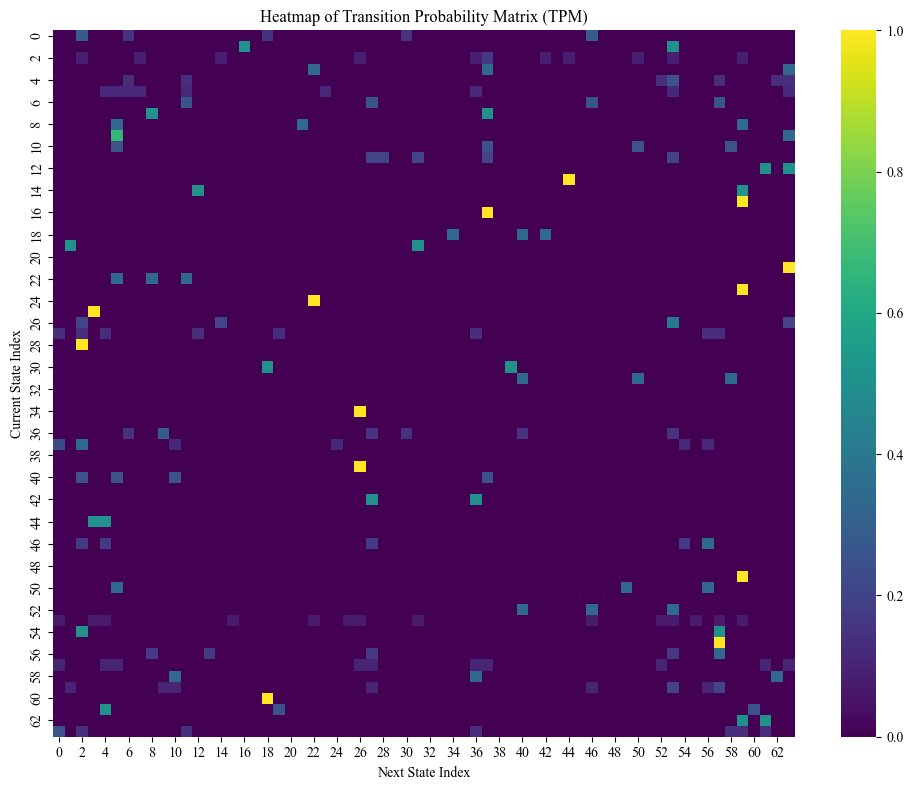

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the font to Times New Roman globally
plt.rcParams['font.family'] = 'Times New Roman'

# tpm is a (64 × 64) matrix if 6 neurons
plt.figure(figsize=(10, 8))
sns.heatmap(tpm, cmap='viridis', cbar=True)

plt.title("Heatmap of Transition Probability Matrix (TPM)")
plt.xlabel("Next State Index")
plt.ylabel("Current State Index")
plt.tight_layout()

# Save the plot before showing it
plt.savefig('TPM_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



In [32]:
plt.savefig("Heatmap_of_TPM.png", dpi=300)


<Figure size 640x480 with 0 Axes>

In [7]:
num_nodes = int(np.log2(tpm.shape[0]))

# Create fully connected connectivity matrix (no self-connections)
connectivity = np.ones((num_nodes, num_nodes), dtype=int) - np.eye(num_nodes, dtype=int)

print(connectivity)

[[0 1 1 1 1 1]
 [1 0 1 1 1 1]
 [1 1 0 1 1 1]
 [1 1 1 0 1 1]
 [1 1 1 1 0 1]
 [1 1 1 1 1 0]]


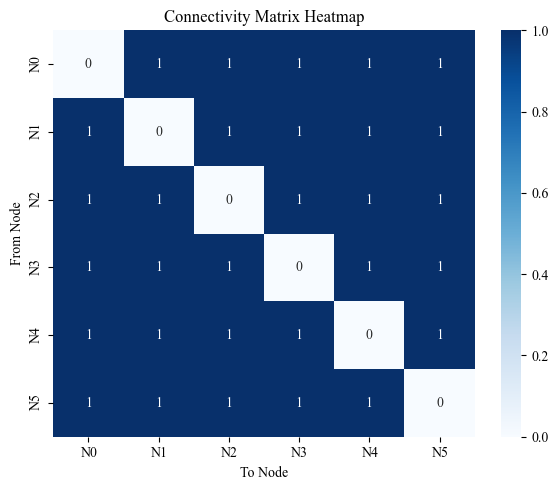

In [8]:
# Optional: Label nodes
node_labels = [f'N{i}' for i in range(connectivity.shape[0])]

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(connectivity, annot=True, cmap='Blues', xticklabels=node_labels, yticklabels=node_labels, cbar=True)

plt.title("Connectivity Matrix Heatmap")
plt.xlabel("To Node")
plt.ylabel("From Node")
plt.tight_layout()

# Save the plot before showing it
plt.savefig('connectivity_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()



In [30]:
plt.savefig("connectivity_heatmap.png", dpi=300)



<Figure size 640x480 with 0 Axes>

# MNIST_CLASSIFICATION_ONLY_FEEDFORWARD

In [3]:
import numpy as np
import pandas as pd
import pyphi
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False


# Define number of nodes (2^n = rows in TPM)
num_nodes = int(np.log2(tpm.shape[0]))

# Connectivity matrix
num_neurons = 6
connectivity = np.zeros((num_neurons, num_neurons), dtype=int)

# PyPhi network
node_labels = ('0','1','2','3','4','5')
network = pyphi.Network(tpm, connectivity, node_labels)

# Initial State(0,0,0,0,0,0)
state = tuple([0] * num_nodes)

# Compute Φ
subsystem = pyphi.Subsystem(network, state)
phi = pyphi.compute.sia(subsystem)

print(f"Φ (phi) for state {state}")
print(phi)



Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'

Φ (phi) for state (0, 0, 0, 0, 0, 0)
┌───────────────────────────────────────┐
│ System irreducibility analysis: Φ = 0 │
│ NullCut((

In [36]:
print(connectivity)

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


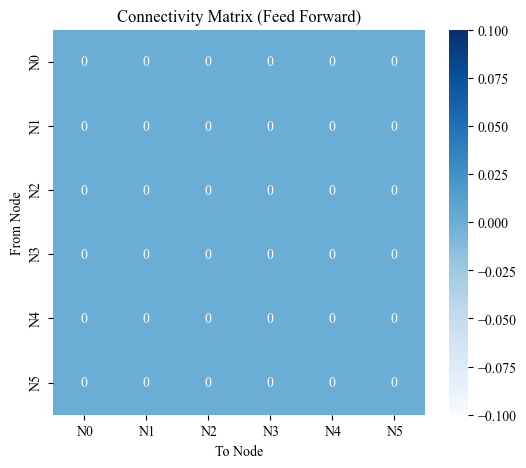

In [10]:
connectivity = np.zeros((6, 6), dtype=int)
node_labels = [f'N{i}' for i in range(6)]

plt.figure(figsize=(6, 5))
sns.heatmap(connectivity, annot=True, cmap='Blues', xticklabels=node_labels, yticklabels=node_labels, cbar=True)

plt.title("Connectivity Matrix (Feed Forward)")
plt.xlabel("To Node")
plt.ylabel("From Node")

plt.savefig('connectivity_mnist_classification_only_feed_forward.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
%%capture captured_output
print(f"Φ (phi) for state {state}")
print(phi)


In [45]:
with open('output.txt', 'w') as f:
    f.write(captured_output.stdout)


In [11]:
connectivity = np.array([
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
], dtype=int)


In [16]:
# -------------------------------
# 9. Compute Φ Using PyPhi
# -------------------------------
PYPHI_WELCOME_OFF='yes'
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

node_labels = [f'N{i}' for i in range(n)]
network = pyphi.Network(tpm, connectivity, node_labels)
state = tuple([0] * n)
subsystem = pyphi.Subsystem(network, state)
phi = pyphi.compute.sia(subsystem)

print(f"\nΦ (phi) for state {state}")
print(phi)


Φ (phi) for state (0, 0, 0, 0, 0, 0)
┌───────────────────────────────────────┐
│ System irreducibility analysis: Φ = 0 │
│    NullCut((0, 1, 2, 3, 4, 5))        │
│ Subsystem(N0, N1, N2, N3, N4, N5)     │
│ ()                                    │
│ ()                                    │
│                                       │
└───────────────────────────────────────┘


In [53]:
%%capture captured_output
print(f"Φ (phi) for state {state}")
print(phi)
with open('minst_classification_pyphi_output1.txt', 'w') as f:
    f.write(captured_output.stdout)

In [55]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 5.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


# FINDING PHI VALUE FOR 2 HIDDEN LAYERS of 3 NEURONS EACH

Epoch 1/5, Loss: 1.4270
Φ (phi) after Epoch 1 = 0.0000
Epoch 2/5, Loss: 0.8701
Φ (phi) after Epoch 2 = 0.0000
Epoch 3/5, Loss: 0.9903
Φ (phi) after Epoch 3 = 0.0000
Epoch 4/5, Loss: 0.6717
Φ (phi) after Epoch 4 = 0.0000
Epoch 5/5, Loss: 0.9335
Φ (phi) after Epoch 5 = 0.0000


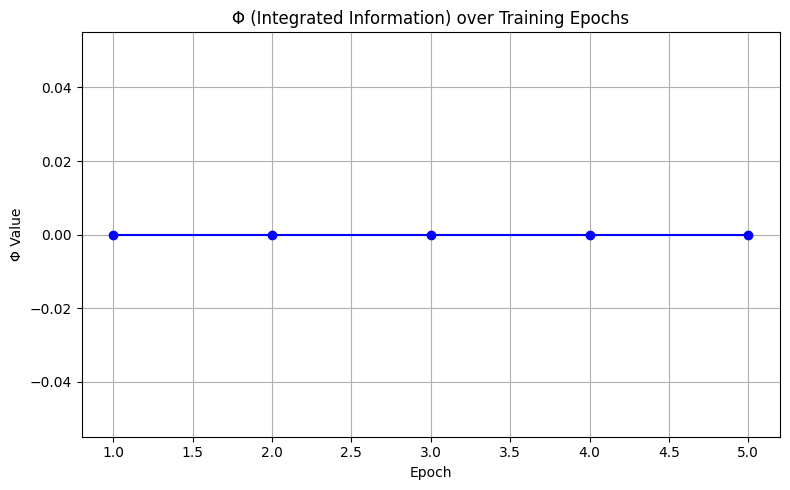

In [11]:
# -------------------------------
# 1. Imports and Setup
# -------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import pyphi

# -------------------------------
# 2. Load MNIST Dataset
# -------------------------------
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# -------------------------------
# 3. Define MLP with 2 Hidden Layers of 3 Neurons Each
# -------------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 3)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(3, 3)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(3, 10)
        self.hidden1 = None
        self.hidden2 = None

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = self.fc1(x)
        self.hidden1 = h1.detach()
        x = self.relu1(h1)
        h2 = self.fc2(x)
        self.hidden2 = h2.detach()
        x = self.relu2(h2)
        x = self.fc3(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 4. Train the Model & Compute Φ
# -------------------------------
epochs = 5
phi_values = []

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # -------------------------------
    # Compute Φ after each epoch
    # -------------------------------
    model.eval()
    activation_list = []
    data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for i, (img, _) in enumerate(data_loader):
            _ = model(img)
            h1 = model.hidden1.squeeze().numpy()  # (3,)
            h2 = model.hidden2.squeeze().numpy()  # (3,)
            combined = np.concatenate([h1, h2])   # (6,)
            activation_list.append(combined)
            if i >= 200:
                break

    activations = np.array(activation_list)  # (201, 6)
    thresholds = np.median(activations, axis=0)
    binarized = (activations > thresholds).astype(int)  # (201, 6)

    n = binarized.shape[1]
    all_states = [tuple(state) for state in product([0, 1], repeat=n)]
    state_to_index = {state: i for i, state in enumerate(all_states)}
    counts = np.zeros((2**n, 2**n))

    for t in range(len(binarized) - 1):
        i = state_to_index[tuple(binarized[t])]
        j = state_to_index[tuple(binarized[t + 1])]
        counts[i][j] += 1

    tpm = np.zeros_like(counts)
    for i in range(counts.shape[0]):
        row_sum = counts[i].sum()
        if row_sum > 0:
            tpm[i] = counts[i] / row_sum

    connectivity = np.array([
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
    ], dtype=int)

    pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False
    pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

    node_labels = [f'N{i}' for i in range(n)]
    network = pyphi.Network(tpm, connectivity, node_labels)
    state = tuple([0] * n)
    subsystem = pyphi.Subsystem(network, state)
    phi = pyphi.compute.sia(subsystem).phi

    phi_values.append(phi)
    print(f"Φ (phi) after Epoch {epoch+1} = {phi:.4f}")

# -------------------------------
# 5. Plot Φ over Epochs
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), phi_values, marker='o', linestyle='-', color='b')
plt.title("Φ (Integrated Information) over Training Epochs")
plt.xlabel("Epoch")
plt.ylabel("Φ Value")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
print(tpm)

[[0.15384615 0.03846154 0.         ... 0.         0.         0.19230769]
 [0.2        0.         0.         ... 0.         0.         0.2       ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         1.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.175      0.025      0.         ... 0.025      0.         0.175     ]]


In [13]:
import pyphi
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyphi.models import Bipartition, Part

# # Example setup: Replace with your actual TPM, connectivity matrix, and node labels
# # Assume a 3-node system for demonstration
# tpm = np.array([
#     [0.1, 0.2, 0.3],  # State (0,0,0)
#     [0.4, 0.5, 0.6],  # State (0,0,1)
#     [0.2, 0.3, 0.4],  # State (0,1,0)
#     [0.5, 0.6, 0.7],  # State (0,1,1)
#     [0.3, 0.4, 0.5],  # State (1,0,0)
#     [0.6, 0.7, 0.8],  # State (1,0,1)
#     [0.4, 0.5, 0.6],  # State (1,1,0)
#     [0.7, 0.8, 0.9]   # State (1,1,1)
# ])
# cm = np.ones((3, 3))  # Fully connected connectivity matrix
# node_labels = ['A', 'B', 'C']
# network = pyphi.Network(tpm, cm, node_labels=node_labels)

# # Define the subsystem (replace with your actual state and nodes)
# state = (1, 0, 0)  # Example state
# nodes = (0, 1, 2)  # All nodes in the subsystem
# subsystem = pyphi.Subsystem(network, state, nodes)

# Compute the MIP (replace with your actual MIP if already computed)
sia = pyphi.compute.subsystem.sia(subsystem)
mip = sia.cut  # The MIP cut
phi = sia.phi  # The φ value for the MIP

# Get the original TPM for the subsystem
original_tpm = subsystem.tpm

# Apply the MIP cut to get the cut TPM
cut_subsystem = subsystem.apply_cut(mip)
cut_tpm = cut_subsystem.tpm

# Compute the difference between original and cut TPM
tpm_diff = original_tpm - cut_tpm
print(cut_tpm)
# # Visualization
# plt.figure(figsize=(15, 5))

# # Plot 1: Original TPM
# plt.subplot(1, 3, 1)
# sns.heatmap(original_tpm, annot=True, cmap='viridis', xticklabels=node_labels, yticklabels=[f'State {i}' for i in range(original_tpm.shape[0])])
# plt.title('Original TPM')

# # Plot 2: MIP-Cut TPM
# plt.subplot(1, 3, 2)
# sns.heatmap(cut_tpm, annot=True, cmap='viridis', xticklabels=node_labels, yticklabels=[f'State {i}' for i in range(cut_tpm.shape[0])])
# plt.title(f'MIP-Cut TPM (φ = {phi:.2f})')

# # Plot 3: Difference (Original - Cut)
# plt.subplot(1, 3, 3)
# sns.heatmap(tpm_diff, annot=True, cmap='coolwarm', center=0, xticklabels=node_labels, yticklabels=[f'State {i}' for i in range(tpm_diff.shape[0])])
# plt.title('TPM Difference (Original - Cut)')

# plt.tight_layout()
# plt.suptitle(f'MIP: {mip}', y=1.05)
# plt.show()

[[[[[[[0.38461538 0.46153846 0.46153846 0.30769231 0.46153846
       0.57692308]
      [0.42857143 0.85714286 0.57142857 0.71428571 0.42857143
       0.71428571]]

     [[0.5        0.5        0.5        0.5        0.5
       0.5       ]
      [0.         0.         0.         0.         0.
       0.        ]]]


    [[[0.         0.         0.         0.         0.
       0.        ]
      [0.         0.         0.         0.         0.
       0.        ]]

     [[0.         0.         0.         0.         0.
       0.        ]
      [0.         0.         0.         0.         0.
       0.        ]]]]



   [[[[0.         0.         0.         0.         0.
       0.        ]
      [0.         0.         0.         0.         0.
       0.        ]]

     [[0.53846154 0.53846154 0.34615385 0.5        0.26923077
       0.53846154]
      [0.5        0.58333333 0.58333333 0.58333333 0.58333333
       0.58333333]]]


    [[[0.         0.         0.         0.         0.
       0.        

In [5]:
import pyphi
print(pyphi.__version__)



1.2.0


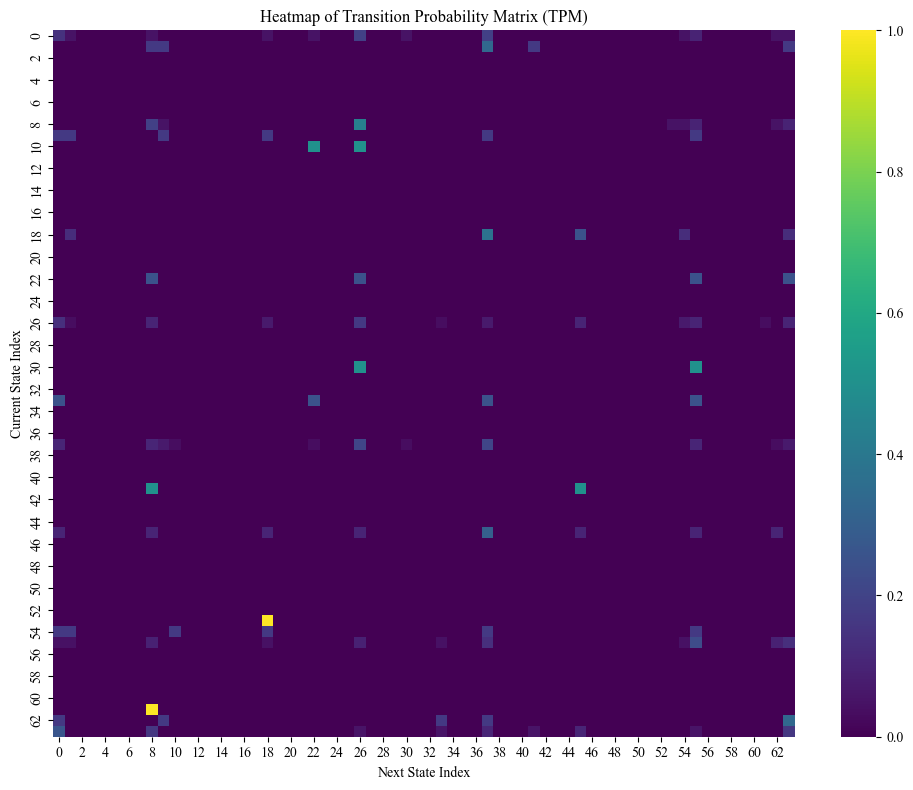

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
# tpm is a (64 × 64) matrix if 6 neurons
plt.figure(figsize=(10, 8))
sns.heatmap(tpm, cmap='viridis', cbar=True)

plt.title("Heatmap of Transition Probability Matrix (TPM)")
plt.xlabel("Next State Index")
plt.ylabel("Current State Index")
plt.tight_layout()

# Save the plot before showing it
plt.savefig('TPM_heatmap_2layers.png', dpi=300, bbox_inches='tight')
plt.show()


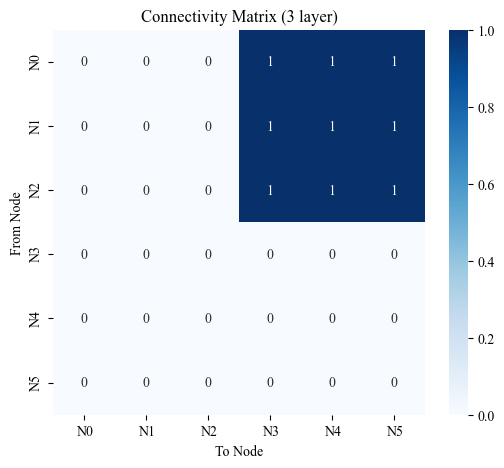

In [13]:

node_labels = [f'N{i}' for i in range(6)]

plt.figure(figsize=(6, 5))
sns.heatmap(connectivity, annot=True, cmap='Blues', xticklabels=node_labels, yticklabels=node_labels, cbar=True)

plt.title("Connectivity Matrix (3 layer)")
plt.xlabel("To Node")
plt.ylabel("From Node")

plt.savefig('connectivity_mnist_classification_only_3_layer.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 4.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.2/731.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 8.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 10.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [streamlit]13 [streamlit]
Note: you may need to restart the kernel to use updated packages.


Epoch 1/5, Loss: 1.3773
Φ (phi) after Epoch 1 = 0.0000


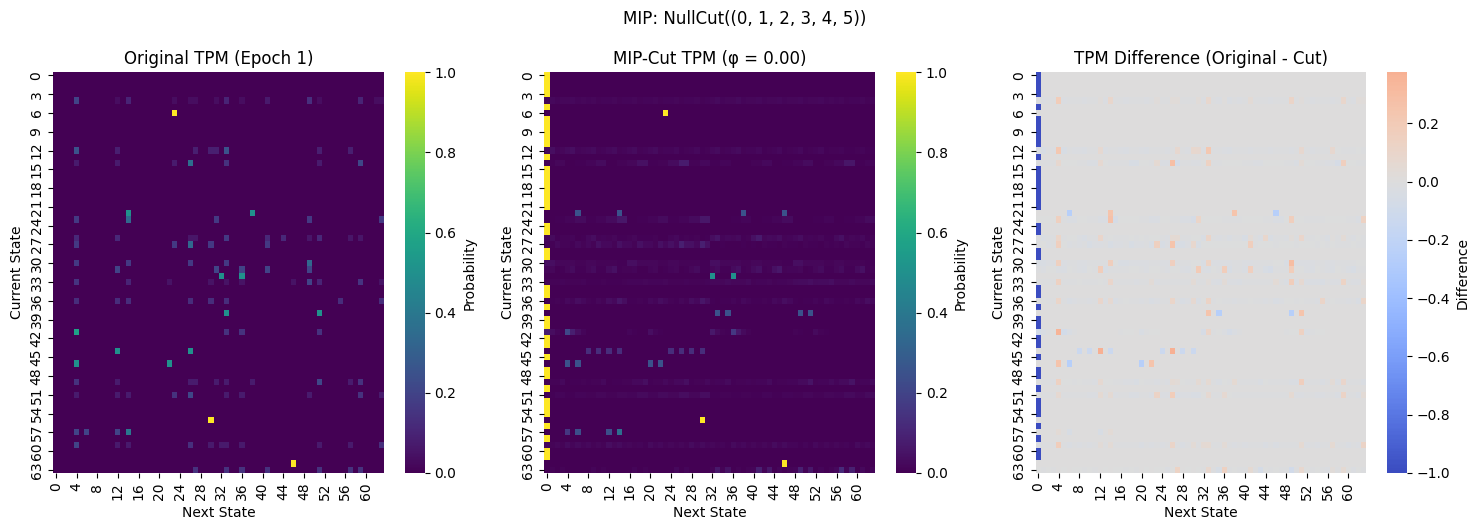

Epoch 2/5, Loss: 1.3393
Φ (phi) after Epoch 2 = 0.0000


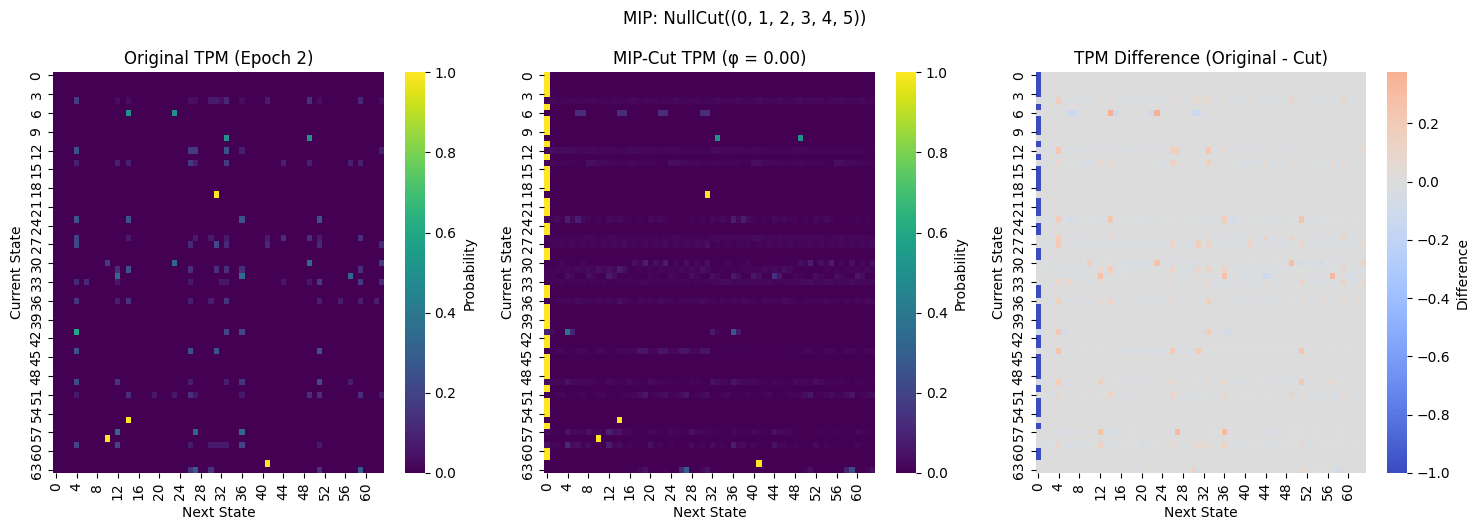

Epoch 3/5, Loss: 1.1471
Φ (phi) after Epoch 3 = 0.0000


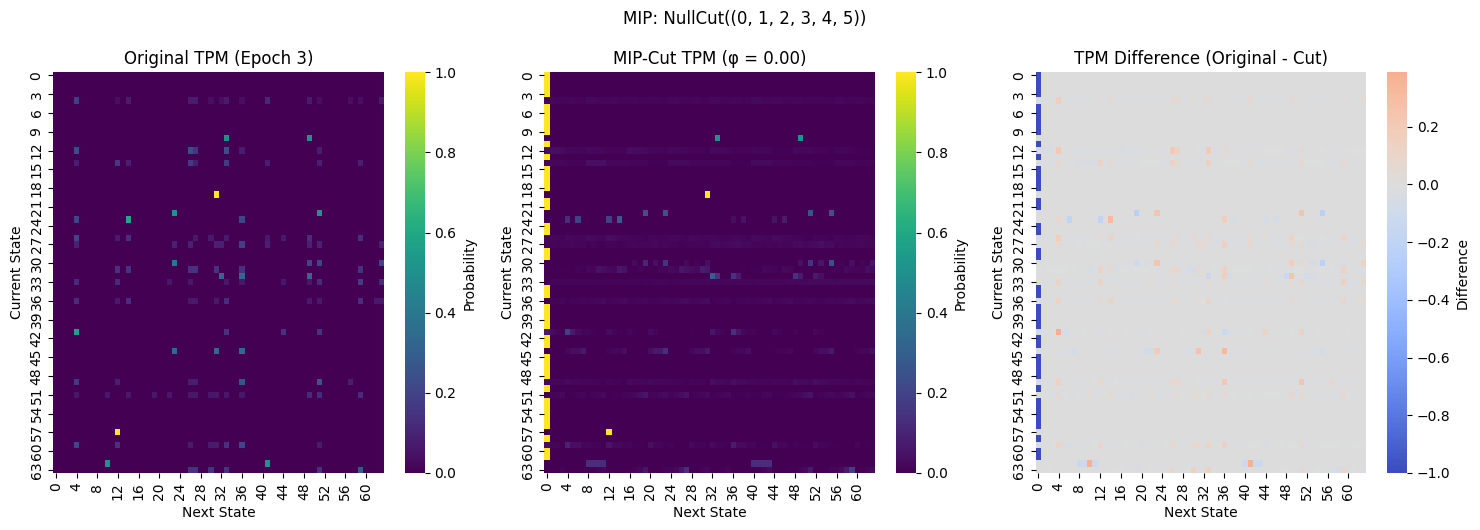

Epoch 4/5, Loss: 0.9516
Φ (phi) after Epoch 4 = 0.0000


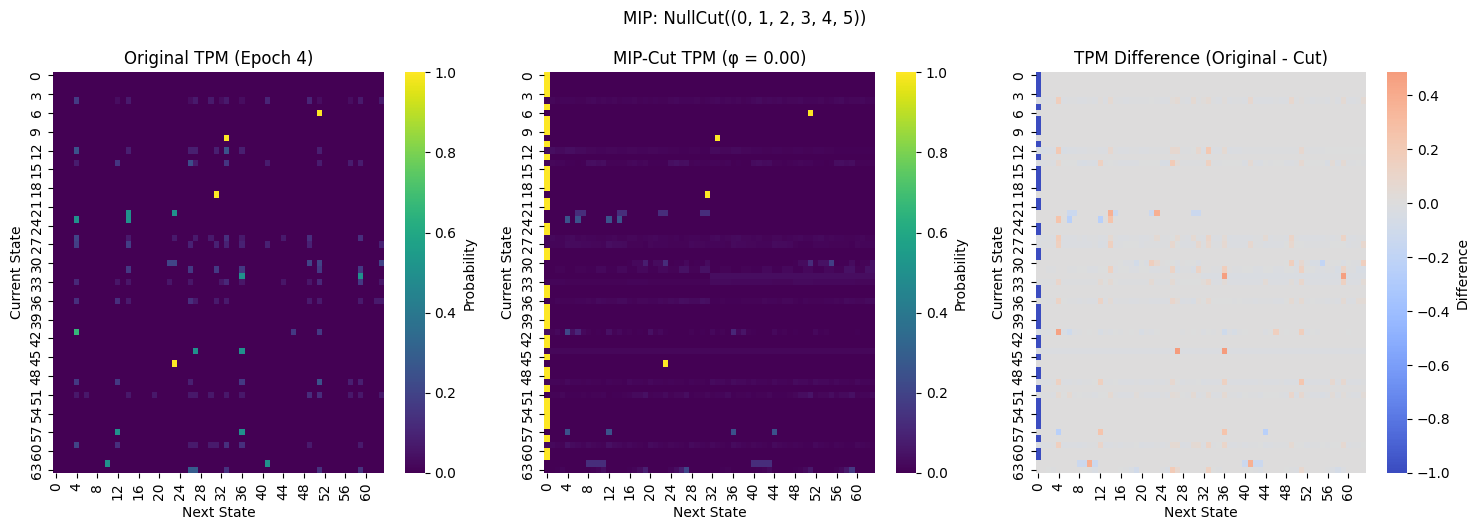

Epoch 5/5, Loss: 1.5489
Φ (phi) after Epoch 5 = 0.0000


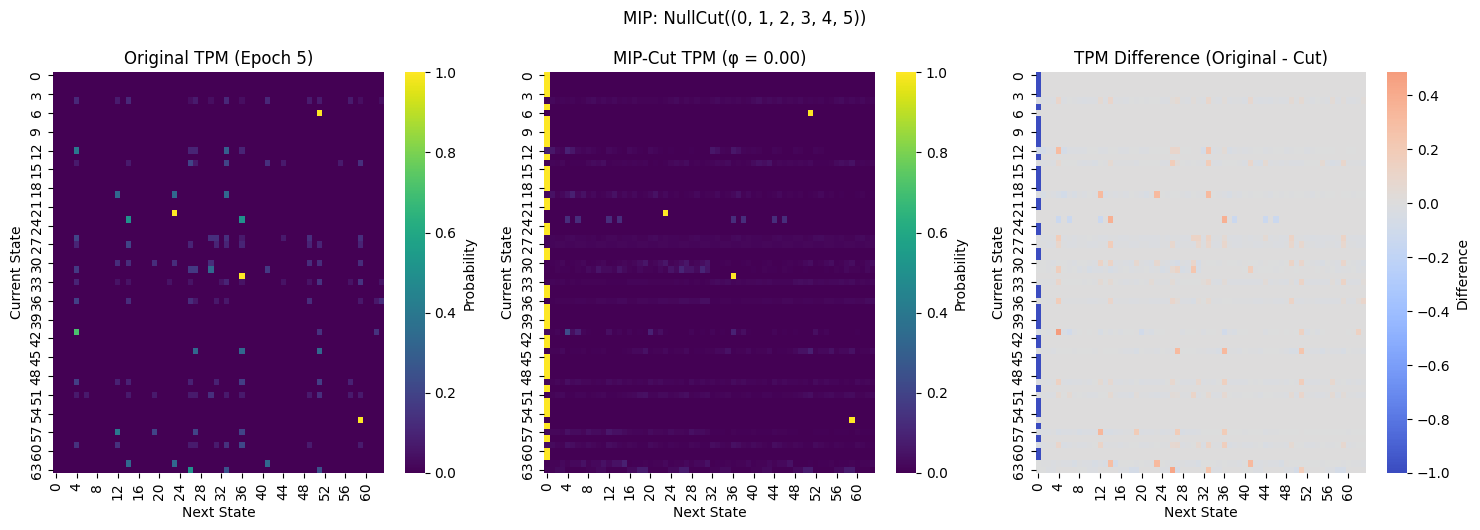

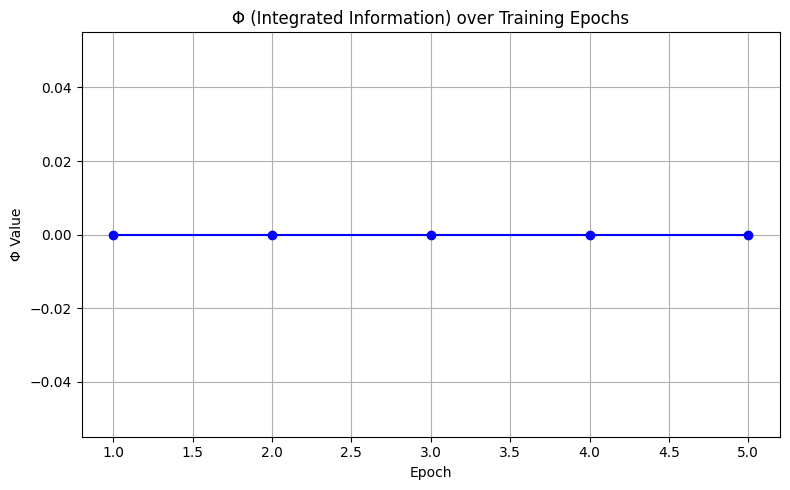

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import pyphi

# -------------------------------
# 1. Load MNIST Dataset
# -------------------------------
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# -------------------------------
# 2. Define MLP with 2 Hidden Layers of 3 Neurons Each
# -------------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 3)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(3, 3)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(3, 10)
        self.hidden1 = None
        self.hidden2 = None

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = self.fc1(x)
        self.hidden1 = h1.detach()
        x = self.relu1(h1)
        h2 = self.fc2(x)
        self.hidden2 = h2.detach()
        x = self.relu2(h2)
        x = self.fc3(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 3. Train the Model & Compute Φ
# -------------------------------
epochs = 5
phi_values = []

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # -------------------------------
    # Compute Φ and TPMs after each epoch
    # -------------------------------
    model.eval()
    activation_list = []
    data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for i, (img, _) in enumerate(data_loader):
            _ = model(img)
            h1 = model.hidden1.squeeze().numpy()  # (3,)
            h2 = model.hidden2.squeeze().numpy()  # (3,)
            combined = np.concatenate([h1, h2])   # (6,)
            activation_list.append(combined)
            if i >= 200:
                break

    activations = np.array(activation_list)  # (201, 6)
    thresholds = np.median(activations, axis=0)
    binarized = (activations > thresholds).astype(int)  # (201, 6)

    n = binarized.shape[1]
    all_states = [tuple(state) for state in product([0, 1], repeat=n)]
    state_to_index = {state: i for i, state in enumerate(all_states)}
    counts = np.zeros((2**n, 2**n))

    for t in range(len(binarized) - 1):
        i = state_to_index[tuple(binarized[t])]
        j = state_to_index[tuple(binarized[t + 1])]
        counts[i][j] += 1

    tpm = np.zeros_like(counts)
    for i in range(counts.shape[0]):
        row_sum = counts[i].sum()
        if row_sum > 0:
            tpm[i] = counts[i] / row_sum

    connectivity = np.array([
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
    ], dtype=int)

    pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False
    pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

    node_labels = [f'N{i}' for i in range(n)]
    network = pyphi.Network(tpm, connectivity, node_labels=node_labels)
    state = tuple([0] * n)
    subsystem = pyphi.Subsystem(network, state)
    sia = pyphi.compute.sia(subsystem)
    phi = sia.phi
    mip = sia.cut  # The MIP cut

    phi_values.append(phi)
    print(f"Φ (phi) after Epoch {epoch+1} = {phi:.4f}")

    # Compute the MIP-cut TPM and convert to state-by-state form
    cut_subsystem = subsystem.apply_cut(mip)
    mip_tpm_state_by_node = cut_subsystem.tpm  # Shape: (2,2,2,2,2,2,6)
    # Convert MIP-cut TPM to state-by-state form to match original tpm
    mip_tpm = pyphi.convert.state_by_node2state_by_state(mip_tpm_state_by_node)  # Shape: (64, 64)

    # Compute the difference between original and MIP-cut TPM
    tpm_diff = tpm - mip_tpm

    # -------------------------------
    # Visualize TPMs and Difference
    # -------------------------------
    plt.figure(figsize=(15, 5))

    # Plot 1: Original TPM
    plt.subplot(1, 3, 1)
    sns.heatmap(tpm, cmap='viridis', cbar_kws={'label': 'Probability'})
    plt.title(f'Original TPM (Epoch {epoch+1})')
    plt.xlabel('Next State')
    plt.ylabel('Current State')

    # Plot 2: MIP-Cut TPM
    plt.subplot(1, 3, 2)
    sns.heatmap(mip_tpm, cmap='viridis', cbar_kws={'label': 'Probability'})
    plt.title(f'MIP-Cut TPM (φ = {phi:.2f})')
    plt.xlabel('Next State')
    plt.ylabel('Current State')

    # Plot 3: Difference (Original - Cut)
    plt.subplot(1, 3, 3)
    sns.heatmap(tpm_diff, cmap='coolwarm', center=0, cbar_kws={'label': 'Difference'})
    plt.title('TPM Difference (Original - Cut)')
    plt.xlabel('Next State')
    plt.ylabel('Current State')

    plt.tight_layout()
    plt.suptitle(f'MIP: {mip}', y=1.05)
    plt.show()

# -------------------------------
# 4. Plot Φ over Epochs
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), phi_values, marker='o', linestyle='-', color='b')
plt.title("Φ (Integrated Information) over Training Epochs")
plt.xlabel("Epoch")
plt.ylabel("Φ Value")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 1/5, Loss: 0.8763
Φ (phi) after Epoch 1 = 0.0000 (using default metric)
Average Wasserstein Distance between TPMs after Epoch 1 = 1.7784


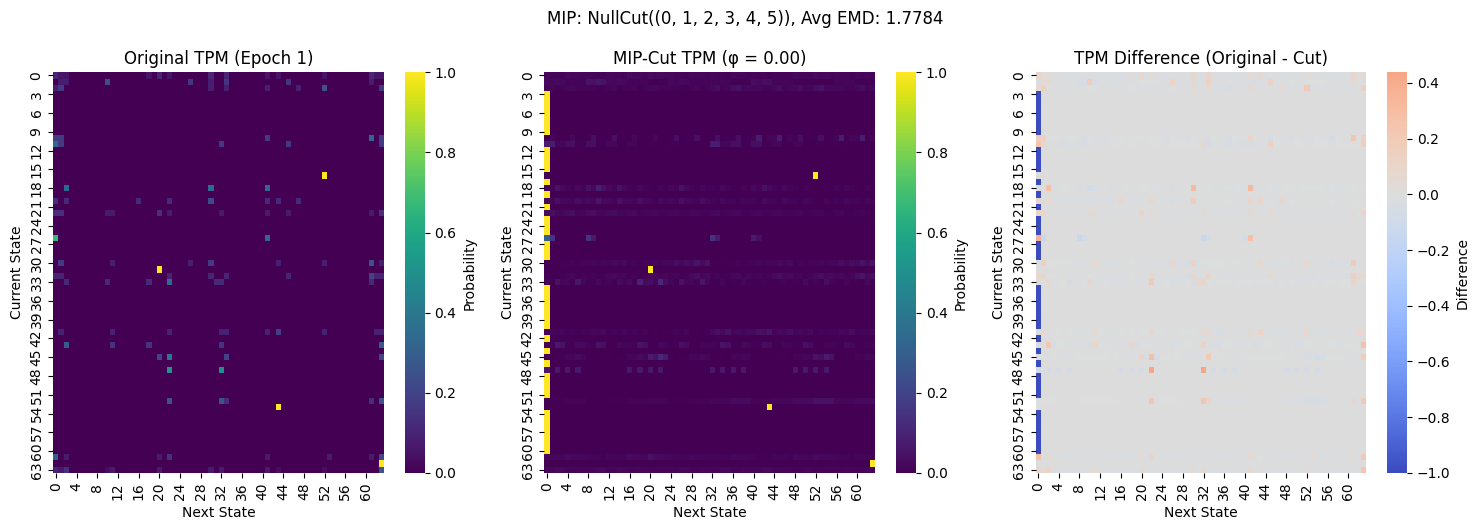

Epoch 2/5, Loss: 0.8610
Φ (phi) after Epoch 2 = 0.0000 (using default metric)
Average Wasserstein Distance between TPMs after Epoch 2 = 2.0970


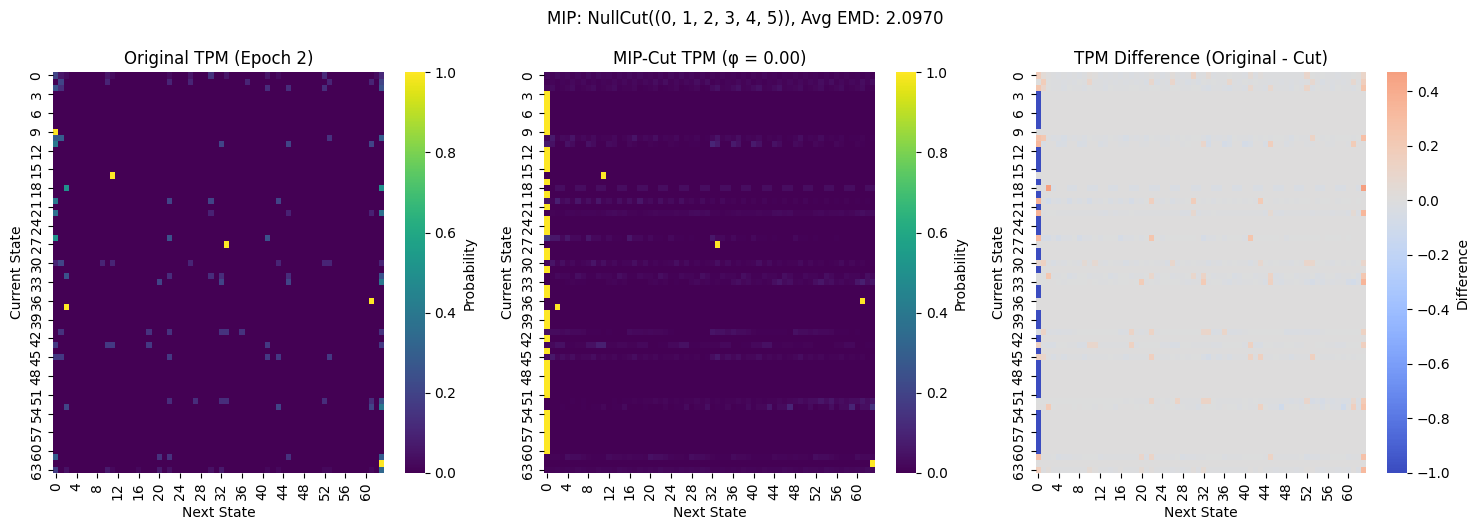

Epoch 3/5, Loss: 0.5991
Φ (phi) after Epoch 3 = 0.0000 (using default metric)
Average Wasserstein Distance between TPMs after Epoch 3 = 2.3086


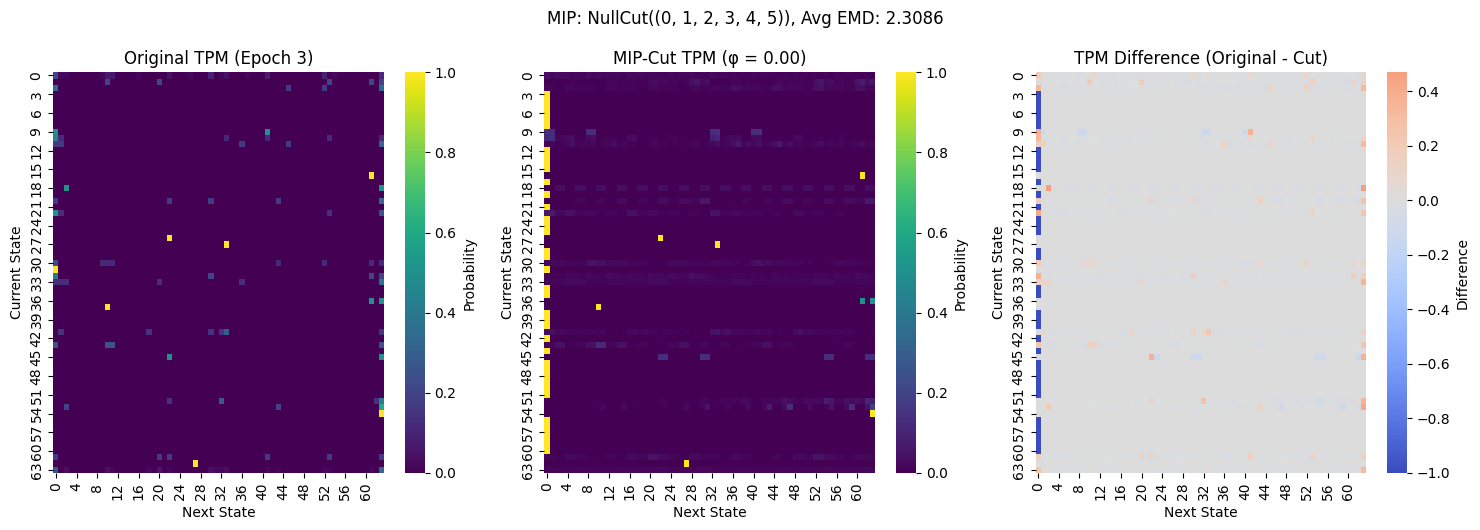

Epoch 4/5, Loss: 0.9869
Φ (phi) after Epoch 4 = 0.0000 (using default metric)
Average Wasserstein Distance between TPMs after Epoch 4 = 2.0902


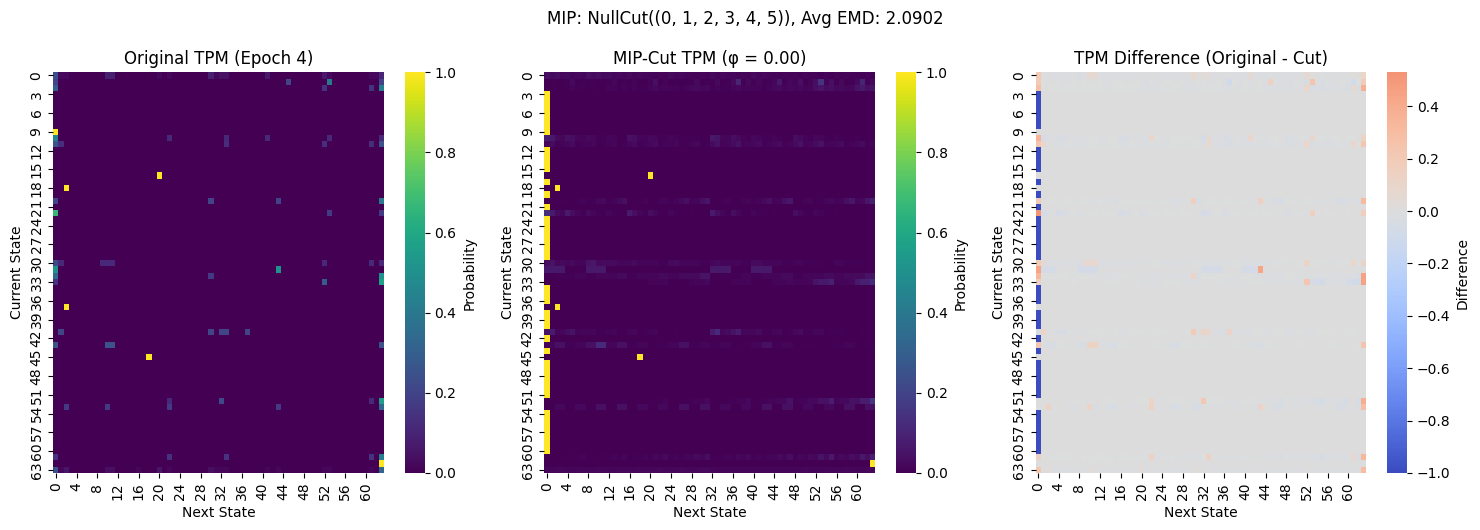

Epoch 5/5, Loss: 1.4051
Φ (phi) after Epoch 5 = 0.0000 (using default metric)
Average Wasserstein Distance between TPMs after Epoch 5 = 2.3899


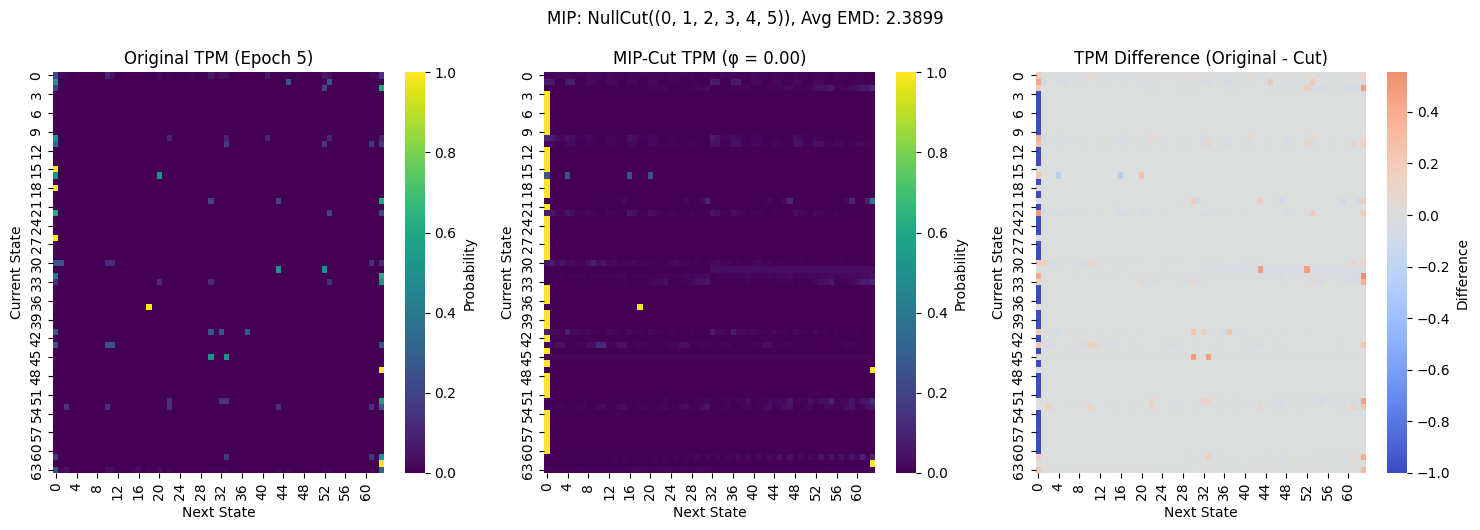

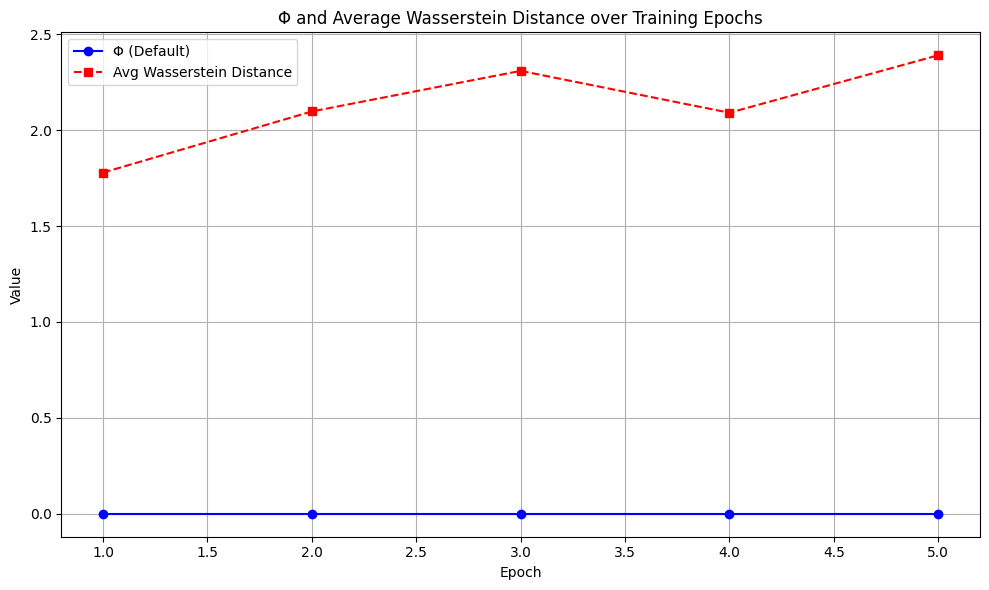

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import pyphi
from scipy.stats import wasserstein_distance

# -------------------------------
# 1. Configure PyPhi (No EMD option in v1.2.0)
# -------------------------------
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

# -------------------------------
# 2. Load MNIST Dataset
# -------------------------------
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# -------------------------------
# 3. Define MLP with 2 Hidden Layers of 3 Neurons Each
# -------------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 3)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(3, 3)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(3, 10)
        self.hidden1 = None
        self.hidden2 = None

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = self.fc1(x)
        self.hidden1 = h1.detach()
        x = self.relu1(h1)
        h2 = self.fc2(x)
        self.hidden2 = h2.detach()
        x = self.relu2(h2)
        x = self.fc3(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 4. Train the Model & Compute Φ
# -------------------------------
epochs = 5
phi_values = []
emd_values = []  # Store custom EMD between TPMs for each epoch

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # -------------------------------
    # Compute Φ and TPMs
    # -------------------------------
    model.eval()
    activation_list = []
    data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for i, (img, _) in enumerate(data_loader):
            _ = model(img)
            h1 = model.hidden1.squeeze().numpy()  # (3,)
            h2 = model.hidden2.squeeze().numpy()  # (3,)
            combined = np.concatenate([h1, h2])   # (6,)
            activation_list.append(combined)
            if i >= 200:
                break

    activations = np.array(activation_list)  # (201, 6)
    thresholds = np.median(activations, axis=0)
    binarized = (activations > thresholds).astype(int)  # (201, 6)

    n = binarized.shape[1]
    all_states = [tuple(state) for state in product([0, 1], repeat=n)]
    state_to_index = {state: i for i, state in enumerate(all_states)}
    counts = np.zeros((2**n, 2**n))

    for t in range(len(binarized) - 1):
        i = state_to_index[tuple(binarized[t])]
        j = state_to_index[tuple(binarized[t + 1])]
        counts[i][j] += 1

    tpm = np.zeros_like(counts)
    for i in range(counts.shape[0]):
        row_sum = counts[i].sum()
        if row_sum > 0:
            tpm[i] = counts[i] / row_sum

    connectivity = np.array([
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
    ], dtype=int)

    node_labels = [f'N{i}' for i in range(n)]
    network = pyphi.Network(tpm, connectivity, node_labels=node_labels)
    state = tuple([0] * n)
    subsystem = pyphi.Subsystem(network, state)
    sia = pyphi.compute.sia(subsystem)
    phi = sia.phi
    mip = sia.cut  # The MIP cut

    phi_values.append(phi)
    print(f"Φ (phi) after Epoch {epoch+1} = {phi:.4f} (using default metric)")

    # Compute the MIP-cut TPM and convert to state-by-state form
    cut_subsystem = subsystem.apply_cut(mip)
    mip_tpm_state_by_node = cut_subsystem.tpm  # Shape: (2,2,2,2,2,2,6)
    mip_tpm = pyphi.convert.state_by_node2state_by_state(mip_tpm_state_by_node)  # Shape: (64, 64)

    # Compute the difference between original and MIP-cut TPM
    tpm_diff = tpm - mip_tpm

    # Compute custom Wasserstein distance between original and MIP-cut TPMs
    emd_sum = 0
    for i in range(tpm.shape[0]):
        orig_dist = tpm[i]
        mip_dist = mip_tpm[i]
        # Ensure distributions are valid (sum to 1 or handle zero-sum rows)
        if orig_dist.sum() > 0 and mip_dist.sum() > 0:
            orig_dist = orig_dist / orig_dist.sum()
            mip_dist = mip_dist / mip_dist.sum()
        else:
            orig_dist = np.ones_like(orig_dist) / len(orig_dist)  # Uniform for zero-sum rows
            mip_dist = np.ones_like(mip_dist) / len(mip_dist)
        emd = wasserstein_distance(np.arange(64), np.arange(64), orig_dist, mip_dist)
        emd_sum += emd
    avg_emd = emd_sum / tpm.shape[0]
    emd_values.append(avg_emd)
    print(f"Average Wasserstein Distance between TPMs after Epoch {epoch+1} = {avg_emd:.4f}")

    # -------------------------------
    # Visualize TPMs and Difference
    # -------------------------------
    plt.figure(figsize=(15, 5))

    # Plot 1: Original TPM
    plt.subplot(1, 3, 1)
    sns.heatmap(tpm, cmap='viridis', cbar_kws={'label': 'Probability'})
    plt.title(f'Original TPM (Epoch {epoch+1})')
    plt.xlabel('Next State')
    plt.ylabel('Current State')

    # Plot 2: MIP-Cut TPM
    plt.subplot(1, 3, 2)
    sns.heatmap(mip_tpm, cmap='viridis', cbar_kws={'label': 'Probability'})
    plt.title(f'MIP-Cut TPM (φ = {phi:.2f})')
    plt.xlabel('Next State')
    plt.ylabel('Current State')

    # Plot 3: Difference (Original - Cut)
    plt.subplot(1, 3, 3)
    sns.heatmap(tpm_diff, cmap='coolwarm', center=0, cbar_kws={'label': 'Difference'})
    plt.title('TPM Difference (Original - Cut)')
    plt.xlabel('Next State')
    plt.ylabel('Current State')

    plt.tight_layout()
    plt.suptitle(f'MIP: {mip}, Avg EMD: {avg_emd:.4f}', y=1.05)
    plt.show()

# -------------------------------
# 5. Plot Φ and Average EMD over Epochs
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), phi_values, marker='o', linestyle='-', color='b', label='Φ (Default)')
plt.plot(range(1, epochs + 1), emd_values, marker='s', linestyle='--', color='r', label='Avg Wasserstein Distance')
plt.title("Φ and Average Wasserstein Distance over Training Epochs")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'

Epoch 1/5, Loss: 1.4398
Φ (phi) after Epoch 1 = 0.0000 (using default metric)
Average Wasserstein Distance between TPMs after Epoch 

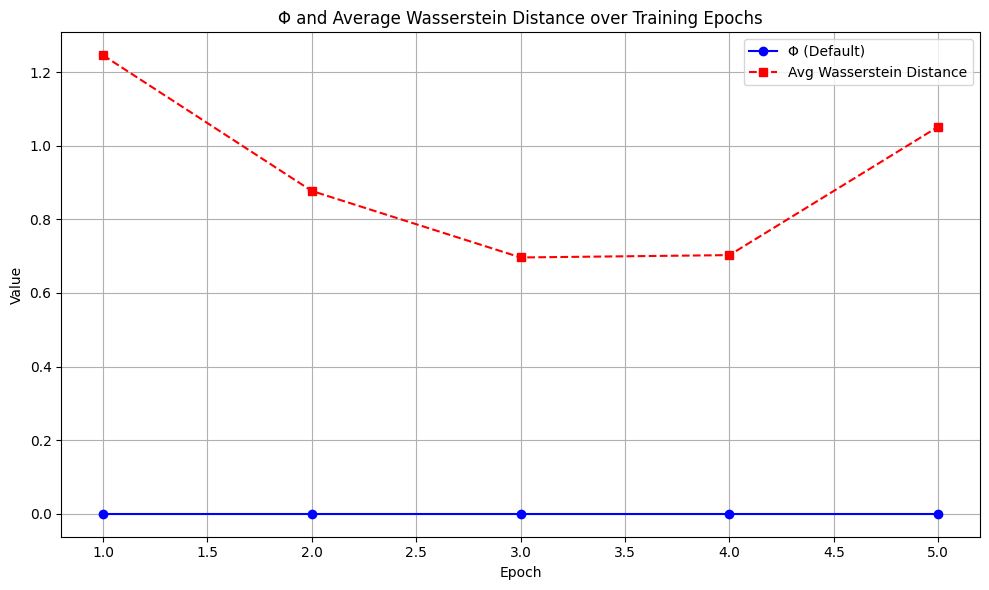

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import pyphi
from scipy.stats import wasserstein_distance
from matplotlib.animation import FuncAnimation

# -------------------------------
# 1. Configure PyPhi (v1.2.0, no EMD option)
# -------------------------------
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

# -------------------------------
# 2. Load MNIST Dataset
# -------------------------------
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# -------------------------------
# 3. Define MLP with 2 Hidden Layers of 3 Neurons Each
# -------------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 3)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(3, 3)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(3, 10)
        self.hidden1 = None
        self.hidden2 = None

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = self.fc1(x)
        self.hidden1 = h1.detach()
        x = self.relu1(h1)
        h2 = self.fc2(x)
        self.hidden2 = h2.detach()
        x = self.relu2(h2)
        x = self.fc3(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 4. Train the Model & Collect TPMs
# -------------------------------
epochs = 5
phi_values = []
emd_values = []
tpm_list = []
mip_tpm_list = []
tpm_diff_list = []
mip_labels = []

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # Compute Φ and TPMs
    model.eval()
    activation_list = []
    data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for i, (img, _) in enumerate(data_loader):
            _ = model(img)
            h1 = model.hidden1.squeeze().numpy()  # (3,)
            h2 = model.hidden2.squeeze().numpy()  # (3,)
            combined = np.concatenate([h1, h2])   # (6,)
            activation_list.append(combined)
            if i >= 200:
                break

    activations = np.array(activation_list)  # (201, 6)
    thresholds = np.median(activations, axis=0)
    binarized = (activations > thresholds).astype(int)  # (201, 6)

    n = binarized.shape[1]
    all_states = [tuple(state) for state in product([0, 1], repeat=n)]
    state_to_index = {state: i for i, state in enumerate(all_states)}
    counts = np.zeros((2**n, 2**n))

    for t in range(len(binarized) - 1):
        i = state_to_index[tuple(binarized[t])]
        j = state_to_index[tuple(binarized[t + 1])]
        counts[i][j] += 1

    tpm = np.zeros_like(counts)
    for i in range(counts.shape[0]):
        row_sum = counts[i].sum()
        if row_sum > 0:
            tpm[i] = counts[i] / row_sum

    connectivity = np.array([
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
    ], dtype=int)

    node_labels = [f'N{i}' for i in range(n)]
    network = pyphi.Network(tpm, connectivity, node_labels=node_labels)
    state = tuple([0] * n)
    subsystem = pyphi.Subsystem(network, state)
    sia = pyphi.compute.sia(subsystem)
    phi = sia.phi
    mip = sia.cut  # The MIP cut

    phi_values.append(phi)
    print(f"Φ (phi) after Epoch {epoch+1} = {phi:.4f} (using default metric)")

    # Compute the MIP-cut TPM and convert to state-by-state form
    cut_subsystem = subsystem.apply_cut(mip)
    mip_tpm_state_by_node = cut_subsystem.tpm  # Shape: (2,2,2,2,2,2,6)
    mip_tpm = pyphi.convert.state_by_node2state_by_state(mip_tpm_state_by_node)  # Shape: (64, 64)

    # Compute the difference between original and MIP-cut TPM
    tpm_diff = tpm - mip_tpm

    # Compute custom Wasserstein distance between original and MIP-cut TPMs
    emd_sum = 0
    for i in range(tpm.shape[0]):
        orig_dist = tpm[i]
        mip_dist = mip_tpm[i]
        if orig_dist.sum() > 0 and mip_dist.sum() > 0:
            orig_dist = orig_dist / orig_dist.sum()
            mip_dist = mip_dist / mip_dist.sum()
        else:
            orig_dist = np.ones_like(orig_dist) / len(orig_dist)
            mip_dist = np.ones_like(mip_dist) / len(mip_dist)
        emd = wasserstein_distance(np.arange(64), np.arange(64), orig_dist, mip_dist)
        emd_sum += emd
    avg_emd = emd_sum / tpm.shape[0]
    emd_values.append(avg_emd)
    print(f"Average Wasserstein Distance between TPMs after Epoch {epoch+1} = {avg_emd:.4f}")

    # Store TPMs and MIP for animation
    tpm_list.append(tpm)
    mip_tpm_list.append(mip_tpm)
    tpm_diff_list.append(tpm_diff)
    mip_labels.append(str(mip))

# -------------------------------
# 5. Animate TPMs
# -------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("TPM Evolution Over Epochs", y=1.05)

# Initialize heatmaps
cbar_kws = {'label': 'Probability'}
cbar_diff_kws = {'label': 'Difference'}
sns.heatmap(tpm_list[0], cmap='viridis', ax=ax1, cbar_kws=cbar_kws)
sns.heatmap(mip_tpm_list[0], cmap='viridis', ax=ax2, cbar_kws=cbar_kws)
sns.heatmap(tpm_diff_list[0], cmap='coolwarm', center=0, ax=ax3, cbar_kws=cbar_diff_kws)
ax1.set_title("Original TPM (Epoch 1)")
ax2.set_title(f"MIP-Cut TPM (φ = {phi_values[0]:.2f})")
ax3.set_title("TPM Difference (Original - Cut)")
ax1.set_xlabel("Next State")
ax1.set_ylabel("Current State")
ax2.set_xlabel("Next State")
ax2.set_ylabel("Current State")
ax3.set_xlabel("Next State")
ax3.set_ylabel("Current State")

def update(frame):
    ax1.clear()
    ax2.clear()
    ax3.clear()
    sns.heatmap(tpm_list[frame], cmap='viridis', ax=ax1, cbar_kws=cbar_kws)
    sns.heatmap(mip_tpm_list[frame], cmap='viridis', ax=ax2, cbar_kws=cbar_kws)
    sns.heatmap(tpm_diff_list[frame], cmap='coolwarm', center=0, ax=ax3, cbar_kws=cbar_diff_kws)
    ax1.set_title(f"Original TPM (Epoch {frame+1})")
    ax2.set_title(f"MIP-Cut TPM (φ = {phi_values[frame]:.2f})")
    ax3.set_title("TPM Difference (Original - Cut)")
    ax1.set_xlabel("Next State")
    ax1.set_ylabel("Current State")
    ax2.set_xlabel("Next State")
    ax2.set_ylabel("Current State")
    ax3.set_xlabel("Next State")
    ax3.set_ylabel("Current State")
    fig.suptitle(f"MIP: {mip_labels[frame]}, Avg EMD: {emd_values[frame]:.4f}", y=1.05)

ani = FuncAnimation(fig, update, frames=epochs, interval=1000)
ani.save("tpm_animation.mp4", writer="ffmpeg")
plt.close()

# -------------------------------
# 6. Plot Φ and Average EMD over Epochs
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), phi_values, marker='o', linestyle='-', color='b', label='Φ (Default)')
plt.plot(range(1, epochs + 1), emd_values, marker='s', linestyle='--', color='r', label='Avg Wasserstein Distance')
plt.title("Φ and Average Wasserstein Distance over Training Epochs")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("phi_emd_plot.png")
plt.show()


Epoch 1/5, Loss: 1.6531
Φ (phi) after Epoch 1 = 0.0000 (using default metric)
Epoch 2/5, Loss: 1.5813
Φ (phi) after Epoch 2 = 0.0000 (using default metric)
Epoch 3/5, Loss: 1.2562
Φ (phi) after Epoch 3 = 0.0000 (using default metric)
Epoch 4/5, Loss: 1.0321
Φ (phi) after Epoch 4 = 0.0000 (using default metric)
Epoch 5/5, Loss: 1.3388
Φ (phi) after Epoch 5 = 0.0000 (using default metric)


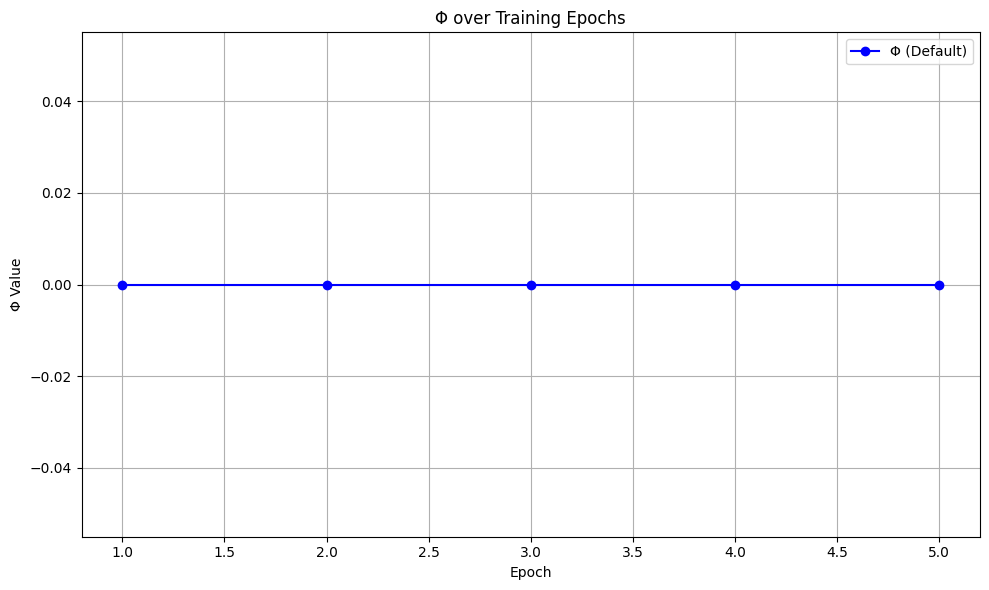

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import pyphi
from matplotlib.animation import FuncAnimation

# -------------------------------
# 1. Configure PyPhi (v1.2.0, no EMD option)
# -------------------------------
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False

# -------------------------------
# 2. Load MNIST Dataset
# -------------------------------
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# -------------------------------
# 3. Define MLP with 2 Hidden Layers of 3 Neurons Each
# -------------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 3)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(3, 3)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(3, 10)
        self.hidden1 = None
        self.hidden2 = None

    def forward(self, x):
        x = x.view(-1, 784)
        h1 = self.fc1(x)
        self.hidden1 = h1.detach()
        x = self.relu1(h1)
        h2 = self.fc2(x)
        self.hidden2 = h2.detach()
        x = self.relu2(h2)
        x = self.fc3(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 4. Train the Model & Collect TPMs
# -------------------------------
epochs = 5
phi_values = []
tpm_list = []
mip_tpm_list = []
tpm_diff_list = []
mip_labels = []

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # Compute Φ and TPMs
    model.eval()
    activation_list = []
    data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for i, (img, _) in enumerate(data_loader):
            _ = model(img)
            h1 = model.hidden1.squeeze().numpy()  # (3,)
            h2 = model.hidden2.squeeze().numpy()  # (3,)
            combined = np.concatenate([h1, h2])   # (6,)
            activation_list.append(combined)
            if i >= 200:
                break

    activations = np.array(activation_list)  # (201, 6)
    thresholds = np.median(activations, axis=0)
    binarized = (activations > thresholds).astype(int)  # (201, 6)

    n = binarized.shape[1]
    all_states = [tuple(state) for state in product([0, 1], repeat=n)]
    state_to_index = {state: i for i, state in enumerate(all_states)}
    counts = np.zeros((2**n, 2**n))

    for t in range(len(binarized) - 1):
        i = state_to_index[tuple(binarized[t])]
        j = state_to_index[tuple(binarized[t + 1])]
        counts[i][j] += 1

    tpm = np.zeros_like(counts)
    for i in range(counts.shape[0]):
        row_sum = counts[i].sum()
        if row_sum > 0:
            tpm[i] = counts[i] / row_sum

    connectivity = np.array([
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
    ], dtype=int)

    node_labels = [f'N{i}' for i in range(n)]
    network = pyphi.Network(tpm, connectivity, node_labels=node_labels)
    state = tuple([0] * n)
    subsystem = pyphi.Subsystem(network, state)
    sia = pyphi.compute.sia(subsystem)
    phi = sia.phi
    mip = sia.cut  # The MIP cut

    phi_values.append(phi)
    print(f"Φ (phi) after Epoch {epoch+1} = {phi:.4f} (using default metric)")

    # Compute the MIP-cut TPM and convert to state-by-state form
    cut_subsystem = subsystem.apply_cut(mip)
    mip_tpm_state_by_node = cut_subsystem.tpm  # Shape: (2,2,2,2,2,2,6)
    mip_tpm = pyphi.convert.state_by_node2state_by_state(mip_tpm_state_by_node)  # Shape: (64, 64)

    # Compute the difference between original and MIP-cut TPM
    tpm_diff = tpm - mip_tpm
    frequent_states = np.where(counts.sum(axis=1) > 0)[0]
    tpm_list.append(tpm[frequent_states][:, frequent_states])
    mip_tpm_list.append(mip_tpm[frequent_states][:, frequent_states])
    tpm_diff_list.append(tpm_diff[frequent_states][:, frequent_states])

    # Store TPMs and MIP for animation
    tpm_list.append(tpm)
    mip_tpm_list.append(mip_tpm)
    tpm_diff_list.append(tpm_diff)
    mip_labels.append(str(mip))

# -------------------------------
# Create Three-Frame Animation for This Epoch (No Colorbar)
# -------------------------------
def create_tpm_animation(epoch, tpm, mip_tpm, diff_tpm, phi, mip_label):
    fig, ax = plt.subplots(figsize=(6, 5))

    def update(frame):
        ax.clear()
        if frame == 0:
            sns.heatmap(tpm, cmap='viridis', ax=ax, cbar=False)
            ax.set_title(f"Original TPM (Epoch {epoch+1})")
        elif frame == 1:
            sns.heatmap(mip_tpm, cmap='viridis', ax=ax, cbar=False)
            ax.set_title(f"MIP-Cut TPM (φ = {phi:.2f})")
        else:  # frame == 2
            sns.heatmap(diff_tpm, cmap='coolwarm', center=0, ax=ax, cbar=False)
            ax.set_title("TPM Difference (Original - Cut)")

        ax.set_xlabel("Next State")
        ax.set_ylabel("Current State")
        fig.suptitle(f"MIP: {mip_label}", y=1.02)

    ani = FuncAnimation(fig, update, frames=[0, 1, 2], interval=1000)
    ani.save(f"tpm_epoch_{epoch+1}.mp4", writer="ffmpeg")
    plt.close()

# Call the function here with the data for this epoch
create_tpm_animation(
    epoch,
    tpm_list[-1],         # Original TPM (last added)
    mip_tpm_list[-1],     # MIP TPM (last added)
    tpm_diff_list[-1],    # Diff TPM (last added)
    phi_values[-1],       # Current phi
    mip_labels[-1]        # Current MIP label
)


# -------------------------------
# 5. Plot Φ over Epochs
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), phi_values, marker='o', linestyle='-', color='b', label='Φ (Default)')
plt.title("Φ over Training Epochs")
plt.xlabel("Epoch")
plt.ylabel("Φ Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("phi_plot.png")
plt.show()